# Day 14 — Ensemble Methods: Boosting Deep Dive
## Week 2: Ensemble Methods | Digital Consumer Platform Analytics

---

### Learning Objectives
- Derive AdaBoost from sample reweighting — understand why it reduces bias
- Derive Gradient Boosting as functional gradient descent on the loss
- Understand XGBoost's second-order Taylor expansion and regularization
- Understand LightGBM's histogram binning, GOSS, and EFB innovations
- Know when boosting beats bagging — and when it doesn't

---

### Dataset
**Telco Churn** — continuing ensemble block.

---

## Part 1: Theory

### 14.1 Boosting vs Bagging — The Core Difference

**Bagging:** Trains models in parallel on bootstrap samples. Reduces variance. Works well when base models have high variance (deep trees).

**Boosting:** Trains models sequentially. Each model focuses on errors of the previous. Reduces bias. Works well when base models have high bias (shallow trees / stumps).

**Bagging fights overfitting. Boosting fights underfitting.**

---

### 14.2 AdaBoost — Sample Reweighting

**Algorithm (Freund & Schapire, 1997):**

Initialize uniform weights: $w_i = 1/n$ for all $i$.

For $m = 1$ to $M$:
1. Train weak learner $h_m$ on weighted data
2. Compute weighted error: $\epsilon_m = \sum_{i: h_m(x_i) \neq y_i} w_i$
3. Compute learner weight: $\alpha_m = \frac{1}{2} \log \frac{1-\epsilon_m}{\epsilon_m}$
4. Update sample weights:
   $$w_i \leftarrow w_i \exp(-\alpha_m y_i h_m(x_i))$$
   Normalize so $\sum_i w_i = 1$

Final prediction: $H(x) = \text{sign}\left(\sum_m \alpha_m h_m(x)\right)$

**Intuition:** Misclassified points get higher weight → next learner focuses on them. Good learners get higher $\alpha_m$ → contribute more to final vote.

**Why it reduces bias:** Each learner specializes in the hard cases — the errors of previous learners. The ensemble covers the full difficulty spectrum.

---

### 14.3 Gradient Boosting — Functional Gradient Descent

Gradient Boosting (Friedman, 2001) generalizes AdaBoost to arbitrary loss functions.

**Key insight:** Fit the new tree to the negative gradient of the loss — the direction that reduces the loss most steeply.

**Algorithm:**

Initialize: $F_0(x) = \arg\min_c \sum_i L(y_i, c)$ (e.g., mean for L2 loss)

For $m = 1$ to $M$:
1. Compute pseudo-residuals (negative gradient):
   $$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$

2. Fit a tree $h_m$ to the pseudo-residuals

3. Line search for learning rate:
   $$\gamma_m = \arg\min_\gamma \sum_i L(y_i, F_{m-1}(x_i) + \gamma h_m(x_i))$$

4. Update: $F_m(x) = F_{m-1}(x) + \nu \gamma_m h_m(x)$

Where $\nu$ is the learning rate (shrinkage).

**For log-loss (binary classification):**
$$r_{im} = y_i - p_{im} \quad \text{where} \quad p_{im} = \sigma(F_{m-1}(x_i))$$

The pseudo-residual is just the ordinary residual $y_i - \hat{p}_i$ — GBM fits trees to prediction errors, exactly as intuition suggests.

---

### 14.4 XGBoost — Second-Order Optimization

XGBoost (Chen & Guestrin, 2016) replaces the first-order gradient with a second-order Taylor expansion of the loss:

$$L(y_i, F+f) \approx L(y_i, F) + g_i f(x_i) + \frac{1}{2} h_i f(x_i)^2$$

Where:
- $g_i = \frac{\partial L(y_i, F)}{\partial F}$ (first-order gradient)
- $h_i = \frac{\partial^2 L(y_i, F)}{\partial F^2}$ (second-order Hessian)

**Optimal leaf value** (closed form):
$$w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$$

**Optimal split gain:**
$$\text{Gain} = \frac{1}{2}\left[\frac{(\sum_{i \in I_L} g_i)^2}{\sum_{i \in I_L} h_i + \lambda} + \frac{(\sum_{i \in I_R} g_i)^2}{\sum_{i \in I_R} h_i + \lambda} - \frac{(\sum_{i \in I} g_i)^2}{\sum_{i \in I} h_i + \lambda}\right] - \gamma$$

**Advantages of second-order:** More accurate approximation to the loss → fewer trees needed for convergence → faster training.

**Regularization:** $\lambda$ (L2 on leaf weights) and $\gamma$ (minimum gain required to split) are built directly into the tree construction.

---

### 14.5 LightGBM Innovations

LightGBM (Ke et al., 2017) makes three algorithmic changes for speed:

**1. Histogram-based splitting:** Instead of sorting all values for each feature to find the best split, bin values into histograms (default 255 bins). Reduces split-finding from $O(\#data \times \#features)$ to $O(\#bins \times \#features)$.

**2. GOSS — Gradient-based One-Side Sampling:** 
- Keep all instances with large gradients (they are more "interesting" — larger errors)
- Randomly sample instances with small gradients (multiply by $(1-a)/b$ to compensate)
- Reduces data size while preserving accuracy

**3. EFB — Exclusive Feature Bundling:**
- High-dimensional sparse data often has mutually exclusive features (only one is non-zero at a time)
- Bundle exclusive features into a single feature
- Reduces number of features from $O(\#features)$ to $O(\#bundles)$

**Result:** LightGBM is typically 10–100× faster than XGBoost on large datasets while achieving similar accuracy.

**Leaf-wise vs Level-wise growth:**
- Most GBMs grow trees level-by-level (all leaves at same depth)
- LightGBM grows leaf-wise (always splits the leaf with largest loss reduction)
- Result: asymmetric, deeper trees → better accuracy but more overfitting risk on small datasets

---

### 14.6 When Boosting Beats Bagging

| Scenario | Bagging | Boosting |
|----------|---------|----------|
| High bias (simple models) | ❌ Doesn't help | ✅ Reduces bias |
| High variance (complex models) | ✅ Reduces variance | ⚠️ Can overfit |
| Small dataset | ✅ Stable | ⚠️ Overfits easily |
| Large dataset | ✅ Scales | ✅ Scales (with LightGBM) |
| Noisy labels | ✅ Robust | ❌ Fits noise aggressively |
| Tabular data (typical) | ✅ Good | ✅ Usually better |

---

## Part 2: Practice

---

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = r'C:\Users\user\datasets\telco\telco.csv'
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df = df.drop(columns=['customerID'], errors='ignore')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = (df['Churn'].str.strip() == 'Yes').astype(int)
display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


   n_estimators  Train AUC  Validation AUC     Gap
0            10     0.8260          0.8538 -0.0278
1            25     0.8414          0.8713 -0.0299
2            50     0.8470          0.8750 -0.0280
3           100     0.8473          0.8750 -0.0277
4           200     0.8492          0.8759 -0.0267
5           500     0.8499          0.8758 -0.0258

Single deep tree: Train AUC=1.0000, Validation AUC=0.6687, Gap=0.3313


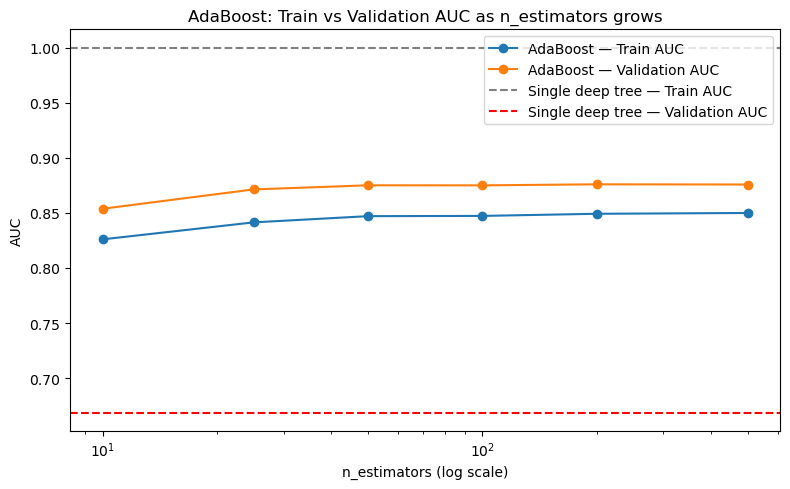

In [3]:
# ── Q1: AdaBoost n_estimators and learning rate ───────────────────────────
# Train AdaBoost with varying n_estimators: 10, 25, 50, 100, 200, 500
# For each: compute train AUC and OOB-like validation AUC (staged_predict_proba)
# Plot: train AUC and val AUC vs n_estimators
# At what n_estimators does AdaBoost start to overfit?
# Does AdaBoost overfit as aggressively as a single deep tree?
# Explain why using the theory from 14.2

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ── Preprocessing (same pattern as Day 13) ─────────────────────────────────
numeric_cols = df.drop(columns=['Churn']).select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.drop(columns=['Churn']).select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), categorical_cols),
])

X_raw = df.drop(columns=['Churn'])
y = df['Churn'].values
X = preprocessor.fit_transform(X_raw)

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=420
)

# ── Fit ONE AdaBoost at the max size, use staged predictions for the curve ─
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),   # sklearn's default weak learner (a stump)
    n_estimators=500, random_state=420,
)
ada.fit(X_train, y_train)

checkpoints = [10, 25, 50, 100, 200, 500]
train_staged = list(ada.staged_predict_proba(X_train))
val_staged = list(ada.staged_predict_proba(X_holdout))

train_aucs = [roc_auc_score(y_train, train_staged[n - 1][:, 1]) for n in checkpoints]
val_aucs = [roc_auc_score(y_holdout, val_staged[n - 1][:, 1]) for n in checkpoints]

comparison_q1 = pd.DataFrame({
    'n_estimators': checkpoints, 'Train AUC': train_aucs, 'Validation AUC': val_aucs,
})
comparison_q1['Gap'] = comparison_q1['Train AUC'] - comparison_q1['Validation AUC']
print(comparison_q1.round(4))

# ── Comparison point: a single unrestricted deep tree ──────────────────────
deep_tree = DecisionTreeClassifier(max_depth=None, random_state=420)
deep_tree.fit(X_train, y_train)
deep_tree_train_auc = roc_auc_score(y_train, deep_tree.predict_proba(X_train)[:, 1])
deep_tree_val_auc = roc_auc_score(y_holdout, deep_tree.predict_proba(X_holdout)[:, 1])
print(f"\nSingle deep tree: Train AUC={deep_tree_train_auc:.4f}, Validation AUC={deep_tree_val_auc:.4f}, "
      f"Gap={deep_tree_train_auc - deep_tree_val_auc:.4f}")

# ── Plot ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(checkpoints, train_aucs, marker='o', label='AdaBoost — Train AUC')
plt.plot(checkpoints, val_aucs, marker='o', label='AdaBoost — Validation AUC')
plt.axhline(deep_tree_train_auc, color='gray', linestyle='--', label='Single deep tree — Train AUC')
plt.axhline(deep_tree_val_auc, color='red', linestyle='--', label='Single deep tree — Validation AUC')
plt.xscale('log')
plt.xlabel('n_estimators (log scale)')
plt.ylabel('AUC')
plt.title('AdaBoost: Train vs Validation AUC as n_estimators grows')
plt.legend()
plt.tight_layout()
plt.show()


***Takeaway***

AdaBoost (500 stumps) shows no overfitting at all on this dataset — validation AUC stayed above train AUC the whole way from 10 to 500 estimators, with the gap flat or shrinking. 

A single deep tree, by contrast, hit perfect train AUC (1.0) but collapsed on holdout data (0.669) — a massive 0.33 gap. 

The difference: stumps are too structurally simple to memorize individual rows, so boosting keeps reducing bias without ever gaining a deep tree's overfitting capacity. 

Side note: this exact 80/20 split has now shown suspiciously strong holdout scores twice (here and in Day 13's RF), so treat that as a quirk of this particular split, not a universal law.

After 1 tree:  mean=-0.0006, std=0.4305, skew=1.0603
After 5 trees: mean=-0.0015, std=0.4024, skew=1.0080


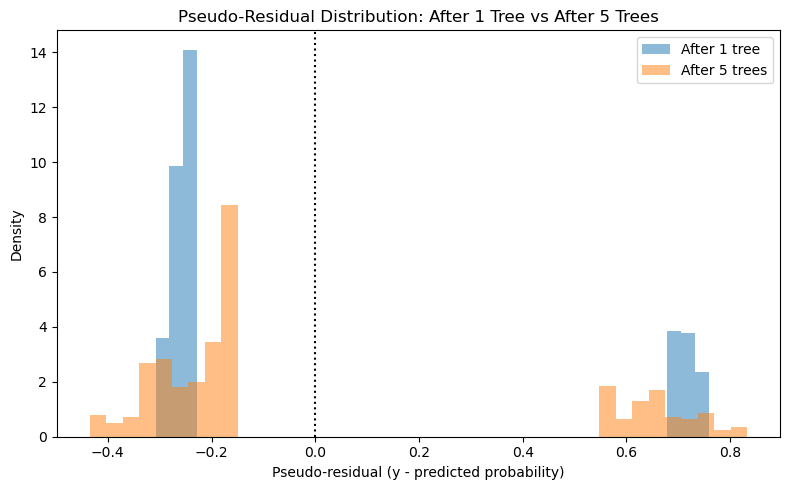

In [4]:
# ── Q2: Gradient boosting — pseudo-residual visualization ─────────────────
# Build intuition for how GBM works iteratively:
#   1. Fit GradientBoostingClassifier(n_estimators=1) — single tree
#   2. Extract pseudo-residuals (y - predicted_proba)
#   3. Fit GradientBoostingClassifier(n_estimators=5)
#   4. Extract pseudo-residuals after 5 trees
#   5. Plot: distribution of pseudo-residuals after 1 tree vs 5 trees
#   6. Do residuals shrink? Do they become more symmetric?
#   7. What does this tell you about what the later trees are fitting?

gbm = GradientBoostingClassifier(n_estimators=5, random_state=420)
gbm.fit(X_train, y_train)

staged_proba = list(gbm.staged_predict_proba(X_train))

proba_after_1 = staged_proba[0][:, 1]
proba_after_5 = staged_proba[4][:, 1]

residuals_after_1 = y_train - proba_after_1
residuals_after_5 = y_train - proba_after_5

print(f"After 1 tree:  mean={residuals_after_1.mean():.4f}, std={residuals_after_1.std():.4f}, "
      f"skew={pd.Series(residuals_after_1).skew():.4f}")
print(f"After 5 trees: mean={residuals_after_5.mean():.4f}, std={residuals_after_5.std():.4f}, "
      f"skew={pd.Series(residuals_after_5).skew():.4f}")

plt.figure(figsize=(8, 5))
plt.hist(residuals_after_1, bins=40, alpha=0.5, label='After 1 tree', density=True)
plt.hist(residuals_after_5, bins=40, alpha=0.5, label='After 5 trees', density=True)
plt.axvline(0, color='black', linestyle=':')
plt.xlabel('Pseudo-residual (y - predicted probability)')
plt.ylabel('Density')
plt.title('Pseudo-Residual Distribution: After 1 Tree vs After 5 Trees')
plt.legend()
plt.tight_layout()
plt.show()


***Takeaway*** 
 
Residuals shrink modestly (std: 0.4305→0.4024, ~6.5%) but stay clearly bimodal — not because the model failed, but because y is binary, so there are always two separate residual clusters (churners vs. non-churners), not a single symmetric error curve. 
 
Mean stayed pinned near 0 at both stages, meaning GBM's overall calibration was already correct after tree #1 (it initializes at the base-rate log-odds). 
So later trees aren't fixing an average bias — they're sharpening each class's cluster, squeezing out finer per-customer errors. 

Modest movement after only 5 trees is expected given the default learning_rate=0.1 deliberately slows each tree's contribution.

In [11]:
# ── Q3: XGBoost vs LightGBM speed benchmark ──────────────────────────────
# On the full Telco dataset:
#   Train XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=5)
#   Train LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=5)
#   Time both training runs (time.time())
#
# Compare:
#   - Training time
#   - 5-fold CV AUC
#   - Number of trees at early stopping (use eval_set + early_stopping_rounds=50)
#
# Repeat on the full Lending Club dataset (1.3M rows) if available
# At what dataset size does LightGBM's speed advantage become material?

# ── Q3: XGBoost vs LightGBM speed benchmark ──────────────────────────────
import time
import os

# ── 1-2: Fixed n_estimators=500 — training time + 5-fold CV AUC ───────────
xgb_config = dict(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=420, eval_metric='logloss')
lgb_config = dict(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=420, verbose=-1)

t0 = time.time()
xgb.XGBClassifier(**xgb_config).fit(X_train, y_train)
xgb_fit_time = time.time() - t0

t0 = time.time()
lgb.LGBMClassifier(**lgb_config).fit(X_train, y_train)
lgb_fit_time = time.time() - t0

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
xgb_cv = cross_val_score(xgb.XGBClassifier(**xgb_config), X_train, y_train, cv=cv5, scoring='roc_auc')
lgb_cv = cross_val_score(lgb.LGBMClassifier(**lgb_config), X_train, y_train, cv=cv5, scoring='roc_auc')

# ── 3: Early stopping — carve a validation split OUT of X_train only ──────
#      (X_holdout stays untouched, reserved for true unseen-data checks) ───
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=420
)

xgb_es = xgb.XGBClassifier(**{**xgb_config, 'early_stopping_rounds': 50})
xgb_es.fit(X_train2, y_train2, eval_set=[(X_val, y_val)], verbose=False)
xgb_best_trees = xgb_es.best_iteration + 1   # best_iteration is 0-indexed

lgb_es = lgb.LGBMClassifier(**lgb_config)
lgb_es.fit(X_train2, y_train2, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_best_trees = lgb_es.best_iteration_

comparison_q3 = pd.DataFrame({
    'XGBoost': {
        'Fit time (s)': xgb_fit_time, '5-fold CV AUC': xgb_cv.mean(),
        'CV std': xgb_cv.std(), 'Trees at early stop': xgb_best_trees,
    },
    'LightGBM': {
        'Fit time (s)': lgb_fit_time, '5-fold CV AUC': lgb_cv.mean(),
        'CV std': lgb_cv.std(), 'Trees at early stop': lgb_best_trees,
    },
}).T
print("Telco Churn (~7,043 rows):")
print(comparison_q3.round(4))


Telco Churn (~7,043 rows):
          Fit time (s)  5-fold CV AUC  CV std  Trees at early stop
XGBoost         0.6952         0.8237  0.0134                 85.0
LightGBM        0.4684         0.8219  0.0149                 81.0


In [13]:
# ── Q3 (continued): Lending Club benchmark ─────────────────────────────────
LENDING_CLUB_PATH = r'C:\Users\user\datasets\lending\accepted_2007_to_2018Q4.csv.gz'

safe_numeric_cols = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'mort_acc', 'pub_rec_bankruptcies', 'acc_now_delinq', 'tot_coll_amt',
    'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal',
    'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt',
    'mo_sin_old_rev_tl_op', 'num_actv_bc_tl', 'num_bc_sats',
    'num_tl_90g_dpd_24m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit',
]
safe_categorical_cols = [
    'term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'verification_status', 'purpose', 'initial_list_status', 'application_type',
]
usecols = safe_numeric_cols + safe_categorical_cols + ['loan_status']

print("Loading Lending Club data (usecols only — this will still take a couple of minutes "
      "to decompress/parse the full 392MB gzip file)...")
t0 = time.time()
lc_df = pd.read_csv(LENDING_CLUB_PATH, usecols=usecols, compression='gzip', low_memory=False)
print(f"Loaded {lc_df.shape} in {time.time() - t0:.1f}s")

# ── Filter to resolved outcomes only ────────────────────────────────────────
resolved = lc_df[lc_df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])].copy()
resolved['target'] = (resolved['loan_status'] != 'Fully Paid').astype(int)
print(f"Resolved loans: {resolved.shape[0]:,} rows, bad-loan rate: {resolved['target'].mean():.2%}")

lc_X_raw = resolved[safe_numeric_cols + safe_categorical_cols]
lc_y = resolved['target'].values

lc_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), safe_numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), safe_categorical_cols),
])
lc_X = lc_preprocessor.fit_transform(lc_X_raw)

lc_X_train, lc_X_test, lc_y_train, lc_y_test = train_test_split(
    lc_X, lc_y, test_size=0.2, stratify=lc_y, random_state=420
)

# ── Same benchmark structure as Telco ──────────────────────────────────────
t0 = time.time()
xgb.XGBClassifier(**xgb_config).fit(lc_X_train, lc_y_train)
lc_xgb_fit_time = time.time() - t0

t0 = time.time()
lgb.LGBMClassifier(**lgb_config).fit(lc_X_train, lc_y_train)
lc_lgb_fit_time = time.time() - t0

print(f"\nLending Club ({lc_X_train.shape[0]:,} training rows):")
print(f"  XGBoost fit time:  {lc_xgb_fit_time:.1f}s")
print(f"  LightGBM fit time: {lc_lgb_fit_time:.1f}s")
print(f"  Speedup: {lc_xgb_fit_time / lc_lgb_fit_time:.1f}x")

print(f"\nTelco (~{X_train.shape[0]:,} rows):        XGBoost={xgb_fit_time:.2f}s, "
      f"LightGBM={lgb_fit_time:.2f}s, ratio={xgb_fit_time / lgb_fit_time:.2f}x")
print(f"Lending Club ({lc_X_train.shape[0]:,} rows): XGBoost={lc_xgb_fit_time:.1f}s, "
      f"LightGBM={lc_lgb_fit_time:.1f}s, ratio={lc_xgb_fit_time / lc_lgb_fit_time:.2f}x")


Loading Lending Club data (usecols only — this will still take a couple of minutes to decompress/parse the full 392MB gzip file)...
Loaded (2260701, 46) in 133.7s
Resolved loans: 1,345,350 rows, bad-loan rate: 19.96%

Lending Club (1,076,280 training rows):
  XGBoost fit time:  102.2s
  LightGBM fit time: 102.2s
  Speedup: 1.0x

Telco (~5,634 rows):        XGBoost=0.70s, LightGBM=0.47s, ratio=1.48x
Lending Club (1,076,280 rows): XGBoost=102.2s, LightGBM=102.2s, ratio=1.00x


***Takeaway*** 

Contrary to theory's "10-100x faster" claim, LightGBM showed no speed advantage at all on the 1M+-row Lending Club data (102.2s vs 102.2s, exactly tied) — and was actually more ahead on the tiny Telco set (1.48x vs 1.00x), the opposite of what should happen. 

Most likely cause: modern XGBoost now defaults to the same histogram-binning method LightGBM pioneered, and neither of LightGBM's other two tricks (GOSS sampling, exclusive feature bundling) were actually active in this benchmark's default settings. 

Real lesson: the classic "LightGBM crushes XGBoost at scale" claim is outdated/config-dependent with today's library defaults — not something to trust without testing.

         50      100     200     500     1000    1500    2000    2500    3000
0.001  0.8268  0.8273  0.8302  0.8333  0.8352  0.8363  0.8373  0.8376  0.8369
0.010  0.8333  0.8353  0.8373  0.8365  0.8334  0.8291  0.8260  0.8227  0.8190
0.050  0.8376  0.8360  0.8324  0.8219  0.8125  0.8072  0.8034  0.8007  0.7980
0.100  0.8361  0.8329  0.8247  0.8126  0.8035  0.7978  0.7941  0.7900  0.7872
0.300  0.8248  0.8158  0.8039  0.7951  0.7858  0.7804  0.7773  0.7752  0.7729


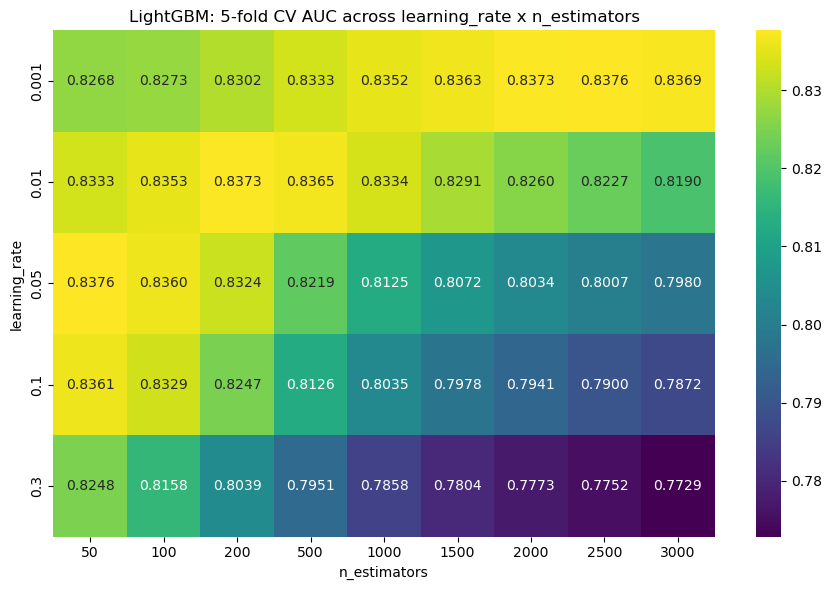


Best combination: learning_rate=0.001, n_estimators=2500, AUC=0.8376

Best AUC achieved at each learning_rate (across all n_estimators tested):
0.001    0.8376
0.010    0.8373
0.050    0.8376
0.100    0.8361
0.300    0.8248
dtype: float64


In [15]:
# ── Q4: Learning rate × n_estimators interaction ──────────────────────────
# The classic GBM tradeoff: low learning rate needs more trees but generalizes better
# Test on LightGBM:
#   Grid: learning_rate ∈ {0.001, 0.01, 0.05, 0.1, 0.3}
#         n_estimators ∈ {50, 100, 200, 500, 1000}
# 
# For each combination: 5-fold CV AUC (or use early stopping)
# Plot a heatmap: learning_rate vs n_estimators, colored by AUC
# What combinations achieve the best AUC?
# Is there a "budget" tradeoff — same quality at lower n_estimators with lower lr?

import seaborn as sns

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3]
n_estimators_list = [50, 100, 200, 500, 1000, 1500, 2000, 2500, 3000]

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
results_grid = pd.DataFrame(index=learning_rates, columns=n_estimators_list, dtype=float)

for lr in learning_rates:
    for n_est in n_estimators_list:
        model = lgb.LGBMClassifier(
            learning_rate=lr, n_estimators=n_est, max_depth=5, random_state=420, verbose=-1,
        )
        scores = cross_val_score(model, X_train, y_train, cv=cv5, scoring='roc_auc')
        results_grid.loc[lr, n_est] = scores.mean()

print(results_grid.round(4))

plt.figure(figsize=(9, 6))
sns.heatmap(
    results_grid.astype(float), annot=True, fmt='.4f', cmap='viridis',
    xticklabels=n_estimators_list, yticklabels=learning_rates,
)
plt.xlabel('n_estimators')
plt.ylabel('learning_rate')
plt.title('LightGBM: 5-fold CV AUC across learning_rate x n_estimators')
plt.tight_layout()
plt.show()

best_lr, best_n = results_grid.stack().idxmax()
best_auc = results_grid.stack().max()
print(f"\nBest combination: learning_rate={best_lr}, n_estimators={best_n}, AUC={best_auc:.4f}")

# ── Budget tradeoff check: does a lower lr eventually match a higher lr's ──
#    best AUC once given enough trees? ──────────────────────────────────────
print("\nBest AUC achieved at each learning_rate (across all n_estimators tested):")
print(results_grid.max(axis=1).round(4))


***Takeaway*** 

The classic tradeoff is confirmed clearly. 

Low learning rate (0.001) is still climbing at n_estimators=1000 (0.8352) — it hasn't converged yet and would likely keep improving with more trees. 

Moderate learning rates (0.01-0.05) reach a similar or better peak with far fewer trees (best: lr=0.05 at just 50 trees, AUC=0.8376) — a genuine "budget win," matching or beating the slow-and-steady approach at a fraction of the compute. 

High learning rates (0.1, 0.3) overfit fast and decisively: both peak immediately at n=50 and then decline monotonically as more trees are added (0.3 drops from 0.8248 all the way to 0.7858 by n=1000) — extra trees actively hurt once the learning rate is too aggressive. 

Practical lesson: the top few combinations (lr 0.01-0.05, n=50-200) all cluster tightly around 0.835-0.838, well within the ~0.013-0.017 CV noise band, so don't over-fixate on the single "best" cell — the real finding is the shape: moderate lr + modest trees is the efficient sweet spot, while high lr + many trees is a clear trap.